In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
directory = os.getcwd()

In [3]:
directory 

'D:\\Python_set\\Python_code\\4_InteractionMARL-Coop-main\\OnlineRetailProject\\purePythonProject\\notebooks'

In [4]:
df = pd.read_csv('../../data/raw/online_retail_II.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.dropna(subset=['Customer ID'], inplace=True)

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
df['InvoiceDate'] = df['InvoiceDate'].dt.to_period('M')

In [10]:
df.describe()

,Quantity,Price,Customer ID
count,797885.000000,797885.000000,797885.000000
mean,12.602980,3.702732,15313.062777
std,191.670371,71.392549,1696.466663
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13964.000000
50%,5.000000,1.950000,15228.000000
75%,12.000000,3.750000,16788.000000
max,80995.000000,38970.000000,18287.000000


In [11]:
df = df[(df['Quantity']>0) & (df['Price']>0)]

In [12]:
df['amount'] = df['Quantity'] * df['Price']

In [13]:
df_orders = (
    df.groupby('Invoice')
    .agg(
        customer = ('Customer ID', 'max'),
        invoicedate = ('InvoiceDate', 'max'),
        total_amount = ('amount', 'sum')
    )
)

In [14]:
df_orders['cohort'] = df_orders.groupby('customer')['invoicedate'].transform('min')

In [15]:
df_orders.head()

,customer,invoicedate,total_amount,cohort
Invoice,,,,
489434,13085.0,2009-12,505.30,2009-12
489435,13085.0,2009-12,145.80,2009-12
489436,13078.0,2009-12,630.33,2009-12
489437,15362.0,2009-12,310.75,2009-12
489438,18102.0,2009-12,2286.24,2009-12


In [16]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36969 entries, 489434 to 581587
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   customer      36969 non-null  float64  
 1   invoicedate   36969 non-null  period[M]
 2   total_amount  36969 non-null  float64  
 3   cohort        36969 non-null  period[M]
dtypes: float64(2), period[M](2)
memory usage: 1.4+ MB


In [17]:
df_orders['cohort_period'] = (df_orders['invoicedate']-df_orders['cohort']).apply(lambda x: x.n)

In [18]:
df_cohort = df_orders.groupby(['cohort', 'cohort_period'], as_index=False).agg(
    customer_cnt = ('customer', 'nunique')
)
df_cohort

,cohort,cohort_period,customer_cnt
0,2009-12,0,955
1,2009-12,1,337
2,2009-12,2,319
3,2009-12,3,406
4,2009-12,4,363
...,...,...,...
320,2011-10,1,71
321,2011-10,2,35
322,2011-11,0,191
323,2011-11,1,27


In [19]:
pt = pd.pivot_table(
    df_cohort,
    values = 'customer_cnt',
    index = 'cohort',
    columns = 'cohort_period',
    aggfunc = 'sum'
)

In [20]:
pt

cohort_period,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
cohort,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
pt.info()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 25 entries, 2009-12 to 2011-12
Freq: M
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       25 non-null     float64
 1   1       24 non-null     float64
 2   2       23 non-null     float64
 3   3       22 non-null     float64
 4   4       21 non-null     float64
 5   5       20 non-null     float64
 6   6       19 non-null     float64
 7   7       18 non-null     float64
 8   8       17 non-null     float64
 9   9       16 non-null     float64
 10  10      15 non-null     float64
 11  11      14 non-null     float64
 12  12      13 non-null     float64
 13  13      12 non-null     float64
 14  14      11 non-null     float64
 15  15      10 non-null     float64
 16  16      9 non-null      float64
 17  17      8 non-null      float64
 18  18      7 non-null      float64
 19  19      6 non-null      float64
 20  20      5 non-null      float64
 21  21      4 non-null   

In [22]:
cohort_size = pt.iloc[:, 0]
retention = pt.div(cohort_size, axis=0)

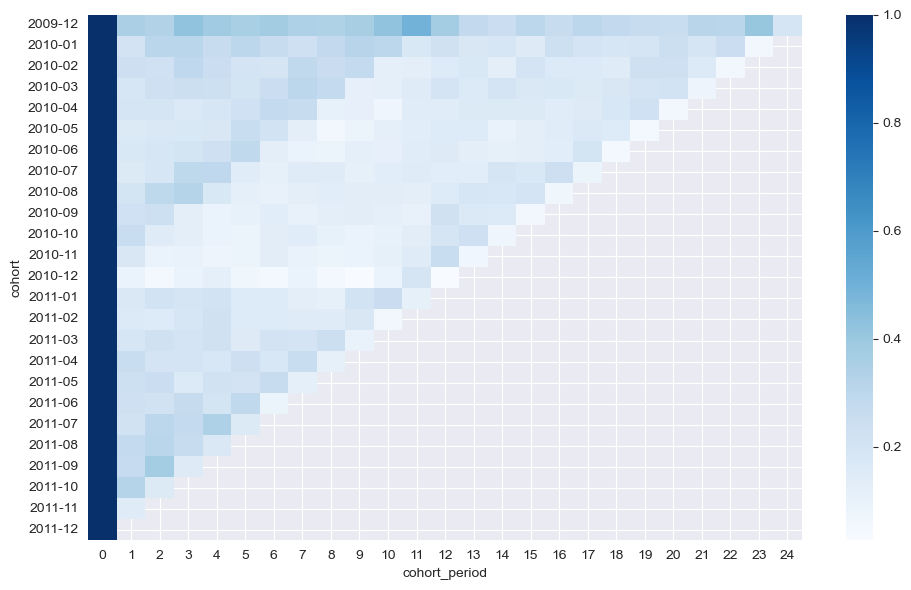

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    retention,
    annot=False,
    fmt='.1%',
    cmap='Blues'
)
plt.tight_layout()
plt.show()